In [80]:
import timeit
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
'''
сравнение различных методов сортировки для массива
'''

In [81]:
def radix_sort(arr, base=10):
    '''
    поразрядная сортировка:
    сортирует числа по разрядам (от младшего к старшему),
    группируя элементы по значению текущего разряда
    '''
    max_digits = max([len(str(x)) for x in arr])
    bins = [[] for _ in range(base)]
    for i in range(0, max_digits):
        for x in arr:
            digit = (x // base ** i) % base
            bins[digit].append(x)
            
        arr = [x for queue in bins for x in queue]
        bins = [[] for _ in range(base)]
        
    return arr

In [82]:
def merge_sort(arr):
    '''
    сортировка слиянием:
    рекурсивно делит массив пополам до отдельных элементов,
    затем собирает его, попарно сливая отсортированные подмассивы
    '''
    if len(arr) <= 1:
        return arr
    
    mid = len(arr) // 2
    left_half = arr[:mid]
    right_half = arr[mid:]
    
    left_sorted = merge_sort(left_half)
    right_sorted = merge_sort(right_half)
    
    return merge(left_sorted, right_sorted)


def merge(left, right):
    result = []
    i = j = 0
    
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    
    while i < len(left):
        result.append(left[i])
        i += 1
    
    while j < len(right):
        result.append(right[j])
        j += 1
    
    return result

In [83]:
def bubble_sort(arr):
    '''
    пузырьковая сортировка:
    многократно проходит по массиву, 
    ставя соседние элементы в порядке неубывания
    '''
    n = len(arr)
    result = arr.copy()
    
    for i in range(n):
        for j in range(0, n - i - 1):
            if result[j] > result[j + 1]:
                result[j], result[j + 1] = result[j + 1], result[j]
    
    return result

In [84]:
def comb_sort(arr):
    '''
    сортировка расческой:
    улучшенная версия пузырьковой
    сравнивает элементы на убывающем расстоянии, 
    что позволяет быстро избавиться от мелких элементов в конце массива
    '''
    n = len(arr)
    result = arr.copy()
    gap = n

    while gap != 1:
        gap = int(gap / 1.247)
        if gap < 1:
            gap = 1
        
        for i in range(0, n - gap):
            if result[i] > result[i + gap]:
                result[i], result[i + gap] = result[i + gap], result[i]
    
    return result

In [85]:
def quicksort(arr):
    '''
    быстрая сортировка:
    выбирает опорный элемент (первый, последний, медианный),
    разделяет массив на элементы меньше и больше него,
    затем рекурсивно применяет тот же процесс к полученным подмассивам
    '''
    if len(arr) <= 1:
        return arr

    pivot = arr[0]
    
    left = [x for x in arr[1:] if x <= pivot]
    right = [x for x in arr[1:] if x > pivot]

    return quicksort(left) + [pivot] + quicksort(right)

In [86]:
def python_sort(arr):
    '''встроенная сортировка python'''
    return sorted(arr)

In [87]:
arr = [137137105157, 24395739293, 474290561035, 5, 276, 42]

sort_list = [radix_sort, merge_sort, bubble_sort, comb_sort, quicksort, python_sort]
algorithms = ['radix', 'merge', 'bubble', 'comb', 'quick', 'python']

In [88]:
heat_data = []
for f in sort_list:
    result = %timeit -n 100000 -r 5 -o f(arr.copy())
    heat_data.append(result.best)

times_array = np.array(heat_data)

29.1 μs ± 504 ns per loop (mean ± std. dev. of 5 runs, 100,000 loops each)
4.55 μs ± 110 ns per loop (mean ± std. dev. of 5 runs, 100,000 loops each)
2.49 μs ± 129 ns per loop (mean ± std. dev. of 5 runs, 100,000 loops each)
2.04 μs ± 37.4 ns per loop (mean ± std. dev. of 5 runs, 100,000 loops each)
3.17 μs ± 155 ns per loop (mean ± std. dev. of 5 runs, 100,000 loops each)
383 ns ± 6.68 ns per loop (mean ± std. dev. of 5 runs, 100,000 loops each)


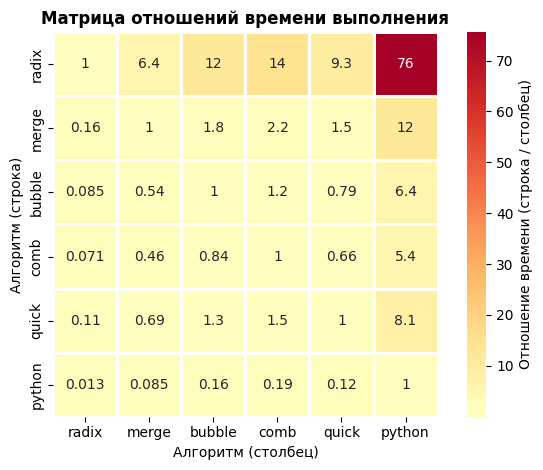

In [89]:
relation_matrix = times_array.reshape(-1, 1) / times_array.reshape(1, -1)

df_relations = pd.DataFrame(relation_matrix, 
                           index=algorithms, 
                           columns=algorithms)

plt.figure()
sns.heatmap(df_relations, annot=True, cmap='RdYlGn_r',
            center=1,
            square=True,
            linewidths=1,
            cbar_kws={'label': 'Отношение времени (строка / столбец)'}
           )

plt.title('Матрица отношений времени выполнения', fontweight='bold')
plt.xlabel('Алгоритм (столбец)')
plt.ylabel('Алгоритм (строка)')
plt.tight_layout()
plt.show()